# Sensor Correction Subroutines

## Introduction

According to experimental results and previous knowledge, It was found that the non uniformity in the circuitry of the CAMIR image sensor can cause that, when exposed by an uniform light source, each pixel has different responsees, generating what are told to be "dead pixels" or "non uniform pixels".

To address this problem it was proposed to correct each pixel by a scale digitally by post processing the frame on an FPGA. In this direction we derive an aproximate model to test posible solution approaches.

For that we create this notebook to explain the solution and evaluate it's performance by comparing a reference model with the resulting correction.

## Theoretical Review

As mentioned before each pixel is a light intensity transducer on an electrical quantity measured by a transducer. This process can be approximated into a linear model that can be represented like following.

$$
p_{i,j,measured} = p_{i,j,real}\cdot \alpha_{i,j,direct} + \beta_{i,j,direct}
$$

Where $p$ represents the intensity of the pixel.

The inverse relation is also linear, so, we can also say that.

$$
p_{i,j,real} = p_{i,j,measured} \cdot \alpha_{i,j,inverse} + \beta_{i,j,inverse}
$$

On that direction the solution to the problem is trivial and we just need "two measurements" and two "real values" in the pixel domain to fit a linear model. The problem arises on what to consider the real value of the pixel to fit the curve. In this methodology we asume that, exposing all pixels to the same intensity of light, understanding, that $\alpha_{i,j,direct} = \alpha_{i,j} + \sigma_{\alpha,i,j}$ and $\beta_{i,j,direct} = \beta_{i,j} + \sigma_{\alpha,i,j}$. The sum of normal distributions is also a normal distribution, than, we can asume that $p_{i,j,measured}$ is also a random variable with normal distribution.

Taking that into account, the real value $p_{i,j,real}$, when the number of sample is too large, approximates the average value $\mu_{p_{i,j}}$ or $\hat{p}_{i,j}$.

$$p_{i,j,real} \approx \hat{p}_{i,j}$$

This result is taken into account and we propose multiple methods of determining the coefficients necessary to solve the calibration problem. The first methodology is the theory verification and the others, production adequate in order to provide automatic calibration methodologies.

## Dependencies

following import dependencies necessary to run this notebook. Don't forget to install the virtual environment with all packages in requirements.txt by running following script.

```bash
python -m venv .venv
source .venv/bin/activate
python -m pip install -r requirements.txt
```

In [6]:
import numpy as np
import matplotlib.pyplot as plt

### Methodology

The following sections describe the methodology to generate reference images and apply a simple sensor model that approximates the real sensor behaviour.

#### Sensor Model

As refered earlier, the pixel model is given by

$$
p_{i,j,measured} = p_{i,j,real} \cdot \alpha_{i,j,inverse} + \beta_{i,j,inverse}
$$

We expand that, knowning that the measured pixel value is an accumulation of measurements we say that.

$$
p_{i,j} = \sum_{k=0}^{N}{ \left ( sensitivity_{i,j} \cdot p_{i,j,measured,k} + \sigma_{i,j}  \right ) }
$$

where $sensitivity$ refers to the pixel sensitivity (that is a random variable) for a given sensor. $N$ is the number of samples taken to "integrate" the image. According to this model we build a python function to apply to the whole "reference" image and try to correct it. with the proposed methodology (linear correction).

In [7]:
# The sensor reference model

def apply_sensor_model(image, pixel_sensitivity_table, mu=0, sigma=1e-6, integration_samples=1000):
    # Get the dimensions of the image
    width, height = image.shape

    # Initialize retval with the first iteration
    retval = image * pixel_sensitivity_table + np.random.normal(mu, sigma, (width, height))

    # Perform the integration over samples
    for i in range(integration_samples):
        retval += image * pixel_sensitivity_table + np.random.normal(mu, sigma, (width, height))

    return retval

#### Reference Image Generation

Here we define two functions, one to generate a ball in the middle of the image, and the other an uniform offset image. Both functions works like the "perfect" images that are going to be submitted to the image sensor model function that generates a noisy image with pixels that aren't corrected.

In [8]:
def generate_image_circle(width, height, x=None, y=None, radius=10, value=0.5, offset=0.25):
    if x is None:
        x = width / 2
    if y is None:
        y = height / 2

    # Create an empty image initialized to zero
    image = np.zeros((width, height))

    # Loop over the image and set pixel values based on distance from (x, y)
    for c in range(width):
        for r in range(height):
            _radius = np.sqrt((x - c) ** 2 + (y - r) ** 2)
            if _radius < radius:
                image[c, r] = value - offset

    # Add the offset to all pixels in the image
    image += offset

    return image

def generate_image_uniform(width=64, height=64, offset=0.0):
    image = offset * np.ones((width, height))
    return image

#### Sensor Sensitivity Table

To address the non uniformity of a sensor we build a function that emulates the gain non uniformity of each pixel to be used in the sensor model.

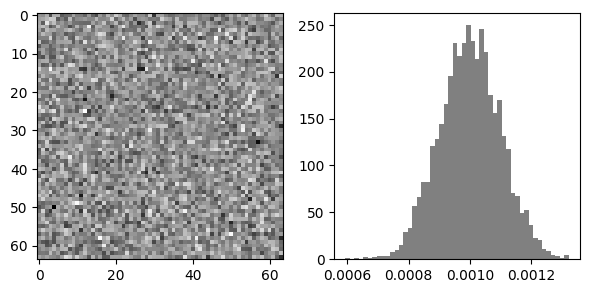

In [17]:
def generate_pixel_sensitivity_table(width=64, height=64, mu=1.0e-3, sigma=0.1e-3):
    return np.random.normal(mu, sigma, (width, height))

# Generate Sensor Characterization
sensor_pixel_sensitivity_table = generate_pixel_sensitivity_table(64, 64)

# Create figure to display all images
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

ax[0].imshow(sensor_pixel_sensitivity_table, cmap='gray')
ax[1].hist(sensor_pixel_sensitivity_table.flatten(), bins=50, color='gray')

plt.tight_layout()
plt.show()

To illustrate that, we take both functions and generate, a single ball image and two reference images and plot all of them with it's corresponding histograms.

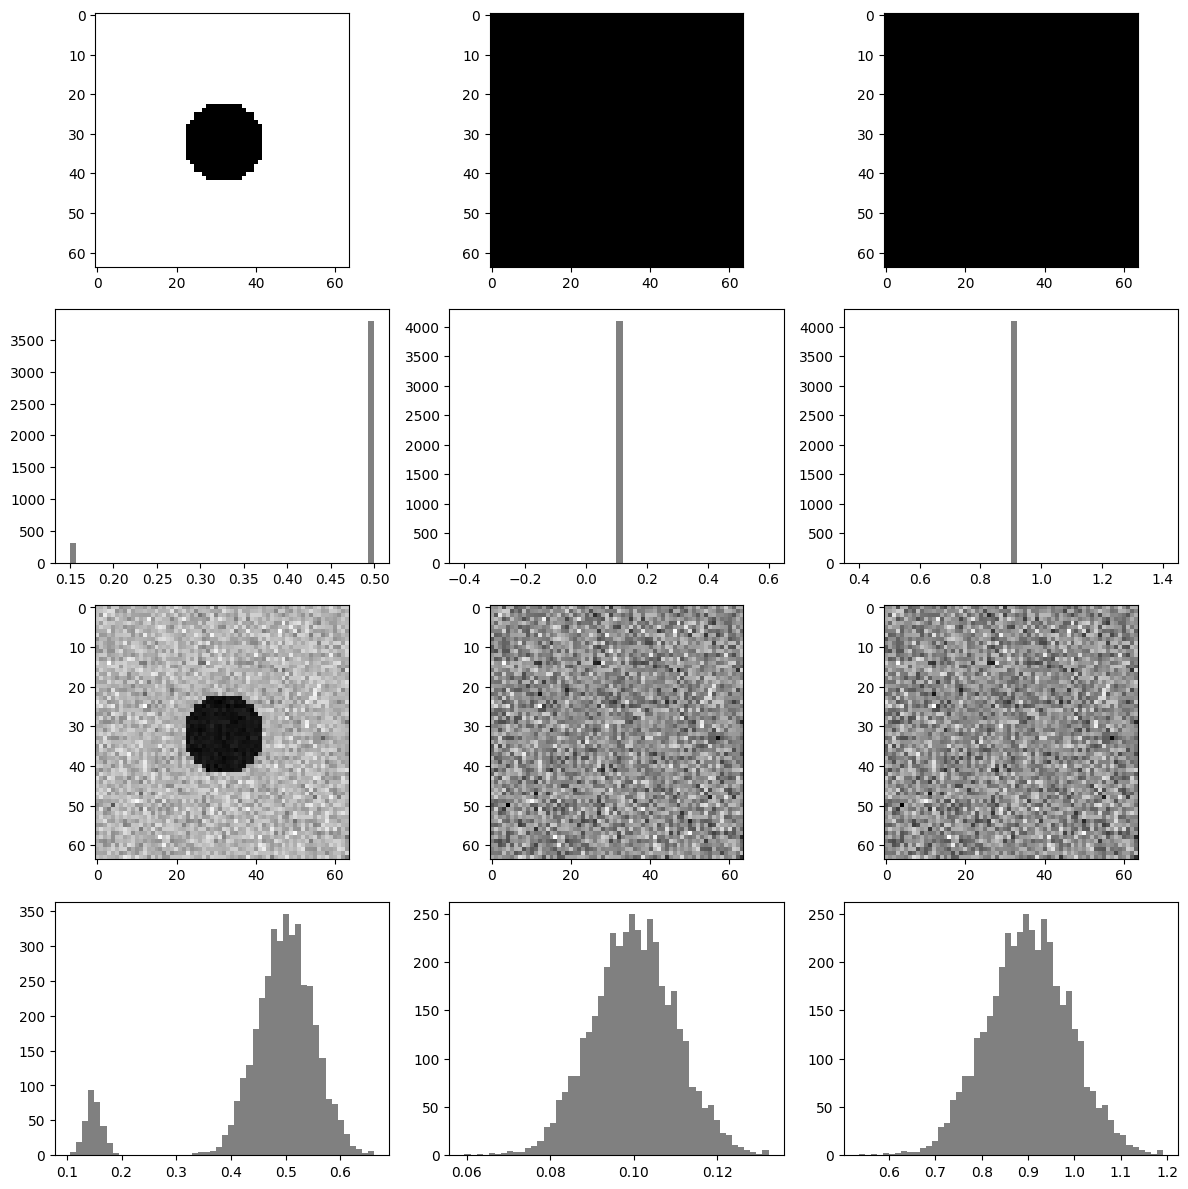

In [18]:
# Generate a Circle Reference Image
image_circle = generate_image_circle(64, 64, 32, 32, 10, 0.15, 0.5)
image_circle_acquired = apply_sensor_model(image_circle, sensor_pixel_sensitivity_table, 0.0, 0.0)

# Generate a Minimum Offset as A Uniform Temperature Reference at Minimum Temperature
image_min = generate_image_uniform(64, 64, 0.1)
image_min_acquired = apply_sensor_model(image_min, sensor_pixel_sensitivity_table, 0.0, 1e-9)

# Apply Sensor Model to Generate Max Temperature Reference Image
image_max = generate_image_uniform(64, 64, 0.9)
image_max_acquired = apply_sensor_model(image_max, sensor_pixel_sensitivity_table, 0.0, 0.0)

# Create figure to display all images
fig, ax = plt.subplots(4, 3, figsize=(12, 12))

# Display the images
ax[0, 0].imshow(image_circle, cmap='gray')
ax[0, 1].imshow(image_min, cmap='gray')
ax[0, 2].imshow(image_max, cmap='gray')

ax[1, 0].hist(image_circle.flatten(), bins=50, color='gray')
ax[1, 1].hist(image_min.flatten(), bins=50, color='gray')
ax[1, 2].hist(image_max.flatten(), bins=50, color='gray')

ax[2, 0].imshow(image_circle_acquired, cmap='gray')
ax[2, 1].imshow(image_min_acquired, cmap='gray')
ax[2, 2].imshow(image_max_acquired, cmap='gray')

# Plot histograms of the acquired images
ax[3, 0].hist(image_circle_acquired.flatten(), bins=50, color='gray')
ax[3, 1].hist(image_min_acquired.flatten(), bins=50, color='gray')
ax[3, 2].hist(image_max_acquired.flatten(), bins=50, color='gray')

plt.tight_layout()
plt.show()

#### Calibration Algorithm

Taken the samples into account, now we need to define a calibration function. That is, for two given measurements, for each pixel, solve the linear system that normalize the pixel response into an uniform response. Later, we apply to the ball to see if it can be recovered with this methodology.

In [ ]:
def calibrate(image_min, image_max):
    # Calculate average values (these are equivalent to the means in Octave)
    p_xy_min = np.mean(image_min)
    p_xy_max = np.mean(image_max)

    # Get the dimensions of the images
    width, height = image_min.shape

    # Initialize the scale and offset arrays with zeros
    scale = np.zeros((width, height))
    offset = np.zeros((width, height))

    # Perform the linear calibration for each pixel
    for i in range(width):
        for j in range(height):
            A = np.array([[image_min[i, j], 1], [image_max[i, j], 1]])
            A_inv = np.linalg.inv(A)  # Inverse of matrix A
            Y = np.array([p_xy_min, p_xy_max])

            # Calculate the linear fit for the pixel
            [_scale, _offset] = np.dot(A_inv, Y)

            scale[i, j] = _scale
            offset[i, j] = _offset

    return scale, offset

def m_ij(arr, i, j):
    _m_ij = 0

    # Iterate over all elements in the array
    for c in range(arr.shape[0]):
        for r in range(arr.shape[1]):
            _m_ij += arr[c, r] * (c + 1) ** i * (r + 1) ** j

    return _m_ij

### Testing and Plotting the Solution

Following this steps, we take into account the two uniform images generated and then get the coefficient tables necessary to fix the image. Then try to fix it by applying a the linear normalization for the whole image.

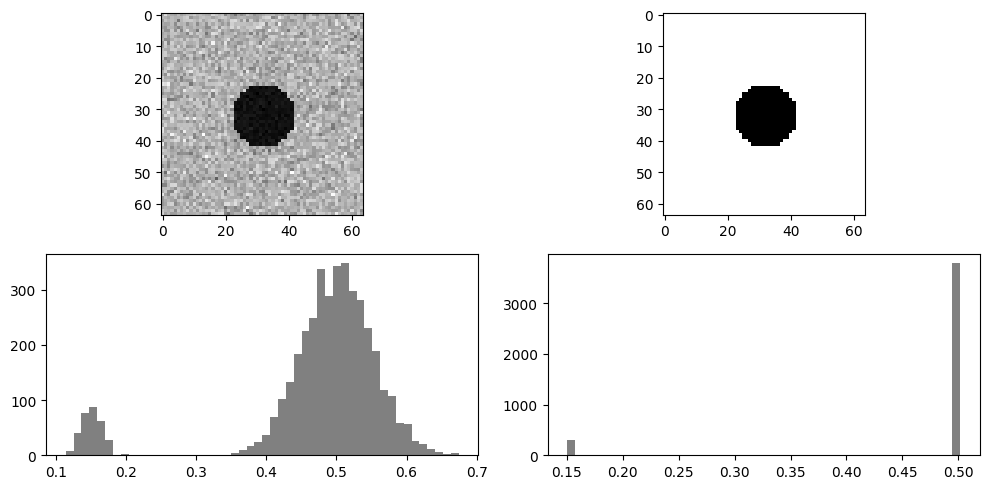

In [ ]:
# Calibrate the sensor using the acquired images
scale, offset = calibrate(image_min_acquired, image_max_acquired)

def apply_normalization(image, scale, offset):
    return image * scale + offset

# Adjust the circle image using the calculated scale and offset
image_circle_adjusted = apply_normalization(image_circle_acquired, scale, offset)

# Create figure to display adjusted image
fig, ax = plt.subplots(2, 2, figsize=(10, 5))

ax[0, 0].imshow(image_circle_acquired, cmap='gray')
ax[0, 1].imshow(image_circle_adjusted, cmap='gray')

# Plot histograms of the acquired images
ax[1, 0].hist(image_circle_acquired.flatten(), bins=50, color='gray')
ax[1, 1].hist(image_circle_adjusted.flatten(), bins=50, color='gray')

plt.tight_layout()
plt.show()

## Conclusions

We can see in the latest picture that after applying the linear correction to the picture, we could not a significant improvement in the sensor response.

Further implementation on real pictures shall be done to test the approach with real images.